In [1]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import zscore
from ctf_dataset.load import create_wrapped_dataset

In [2]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

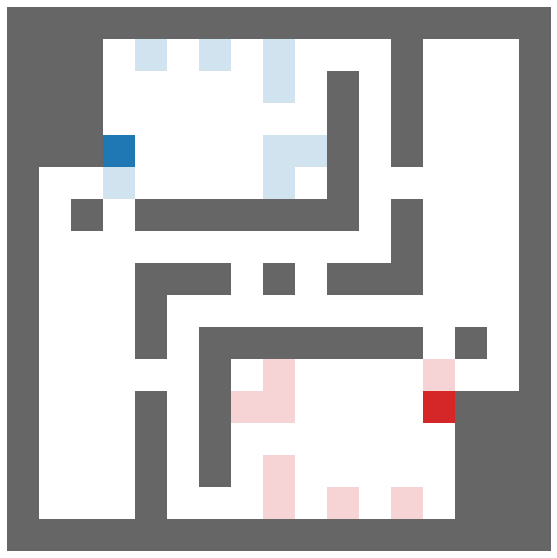

In [24]:
map_id = 5

map_features = wrap_f['map/map_features'][map_id]
map_red_base = np.full(map_features.shape, np.nan)
map_red_base[map_features == 4] = 1
map_red_spawns = np.full(map_features.shape, np.nan)
map_red_spawns[map_features == 2] = 1
map_blue_base = np.full(map_features.shape, np.nan)
map_blue_base[map_features == 5] = 1
map_blue_spawns = np.full(map_features.shape, np.nan)
map_blue_spawns[map_features == 3] = 1
map_features[np.where(map_features != 1)] = 0

fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(map_features, cmap=ListedColormap(['w', '.4']))
ax.matshow(map_red_base, cmap=ListedColormap(['tab:red']))
ax.matshow(map_blue_base, cmap=ListedColormap(['tab:blue']))
ax.matshow(map_red_spawns, cmap=ListedColormap(['tab:red']), alpha=.2)
ax.matshow(map_blue_spawns, cmap=ListedColormap(['tab:blue']), alpha=.2)
plt.axis('off');
plt.savefig(f'figures/map-{map_id}_grid.png', bbox_inches='tight',
            transparent=True, dpi=300)

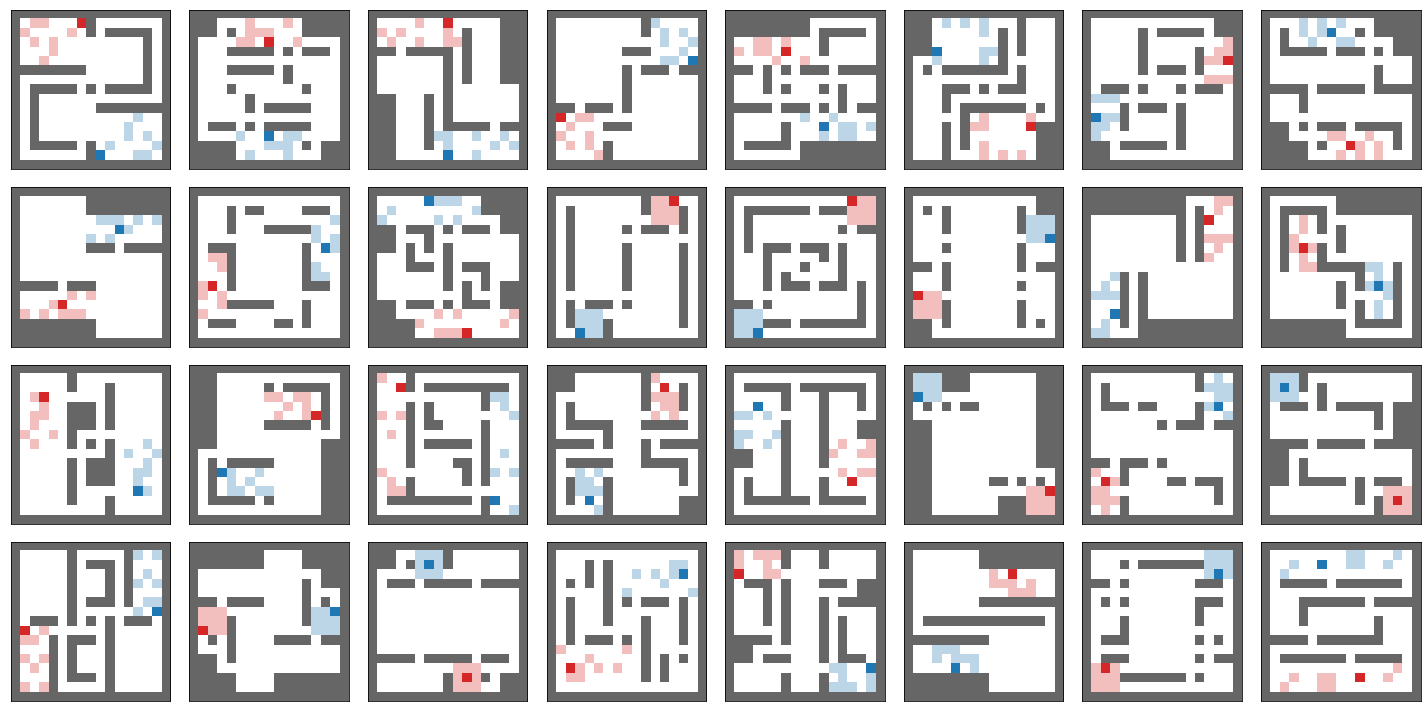

In [25]:
n_maps = 32

fig, axs = plt.subplots(4, 8, figsize=(20, 10))
for ax, map_id in zip(axs.ravel(), np.arange(n_maps)):
    map_features = wrap_f['map/map_features'][map_id]
    
    map_red_base = np.full(map_features.shape, np.nan)
    map_red_base[map_features == 4] = 1
    map_red_spawns = np.full(map_features.shape, np.nan)
    map_red_spawns[map_features == 2] = 1
    
    map_blue_base = np.full(map_features.shape, np.nan)
    map_blue_base[map_features == 5] = 1
    map_blue_spawns = np.full(map_features.shape, np.nan)
    map_blue_spawns[map_features == 3] = 1
    
    map_features[np.where(map_features != 1)] = 0
    
    ax.matshow(map_features, cmap=ListedColormap(['w', '.4']))
    ax.matshow(map_red_base, cmap=ListedColormap(['tab:red']))
    ax.matshow(map_blue_base, cmap=ListedColormap(['tab:blue']))
    ax.matshow(map_red_spawns, cmap=ListedColormap(['tab:red']), alpha=.3)
    ax.matshow(map_blue_spawns, cmap=ListedColormap(['tab:blue']), alpha=.3)
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.savefig('figures/maps_grid.svg', bbox_inches='tight',
            transparent=True, dpi=300)

In [8]:
map_id = 0

map_features = wrap_f['map/map_features'][map_id]

print(map_features.shape)
print(map_features)

(17, 17)
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 2 2 0 0 0 4 1 0 0 0 0 0 0 0 1]
 [1 2 0 0 0 0 2 0 1 0 1 1 1 1 1 0 1]
 [1 0 2 0 2 0 0 0 0 0 0 0 0 0 1 0 1]
 [1 0 0 0 2 0 0 0 0 0 0 0 0 0 1 0 1]
 [1 0 0 2 0 0 0 0 0 0 0 0 0 0 1 0 1]
 [1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]
 [1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 3 0 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0 3 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0 3 0 3 0 1]
 [1 0 1 1 1 1 1 0 1 0 3 0 0 0 0 3 1]
 [1 0 0 0 0 0 0 0 1 5 0 0 0 3 3 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


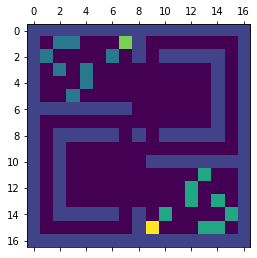

In [14]:
plt.matshow(map_features)

In [15]:
map_features = map_features.ravel()

In [16]:
map_features.shape

(289,)

In [27]:
map_id, matchup_id, repeat_id = 0, 0, 0
r = wrap_f[f'map/matchup/repeat/player/time/reward'][map_id, matchup_id, repeat_id]
r.shape

(4, 4501, 1)

In [ ]:
r

In [139]:
# Load pre-saved PCA-reduced data
matchup_id = 0
map_id = 0
repeat_id = 0

n_maps = 32
n_repeats = 32
n_samples = 4501
n_pcs = 142

lstms_pca = []
for map_id in np.arange(n_maps):
    lstms_pca.append(np.load(f'results/lstms-pca_matchup-{matchup_id}'
                             f'_map-{map_id}_repeat-{repeat_id}.npy')[..., :n_pcs])
lstms_pca = np.stack(lstms_pca, axis=0)

In [143]:
lstms_pca = np.dstack((lstms_pca[:, 0], lstms_pca[:, 1]))

In [144]:
lstms_pca.shape

(32, 4501, 284)

In [145]:
np.where(map_features != 1)

(array([ 0,  0,  0, ..., 31, 31, 31]),
 array([   0,    0,    0, ..., 4500, 4500, 4500]),
 array([ 18,  19,  20, ..., 268, 269, 270]))

In [146]:
map_features = np.array([wrap_f['map/map_features'][map_id].ravel()
                         for map_id in np.arange(n_maps)])
map_features = np.repeat(map_features[:, np.newaxis, :], n_samples, axis=1)
map_features[map_features != 1] = 0

In [147]:
n_minutes = 5
n_seconds = 15 * 60

slice_minutes = [slice(m * n_seconds, m * n_seconds + n_seconds)
                 for m in np.arange(n_minutes)]

In [148]:
minute_id = 4

lstms_minute = np.concatenate(lstms_pca[:, slice_minutes[minute_id]])
maps_minute = np.concatenate(map_features[:, slice_minutes[minute_id]])

maps_minute = maps_minute[:, ~(np.all(maps_minute == 1, axis=0) | np.all(maps_minute == 0, axis=0))]

In [149]:
maps_minute.shape[0] // 32

900

In [150]:
lstms_minute.shape

(28800, 284)

In [151]:
maps_minute.shape

(28800, 189)

In [152]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputRegressor

n_targets = maps_minute.shape[1]

cv = KFold(n_splits=n_repeats)
model = MultiOutputRegressor(
    LogisticRegression(penalty='l2', class_weight='balanced'))

scores = []
for f, (train, test) in enumerate(cv.split(lstms_minute)):
    model.fit(lstms_minute[train], maps_minute[train])
    map_pred = model.predict(lstms_minute[test])
    
    target_scores = []
    for t in np.arange(n_targets):
        target_scores.append(balanced_accuracy_score(maps_minute[test, t], map_pred[:, t]))
    
    scores.append(np.array(target_scores))
    print(f"Finished fold {f}")

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

Finished fold 0


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

Finished fold 1


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

...

Finished fold 14


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

Finished fold 15


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

In [153]:
np.mean(scores)

0.5823089359200471

In [136]:
np.mean(scores)

0.5563899911816579

In [130]:
from sklearn.metrics import balanced_accuracy_score

n_features = maps_minute.shape[1]

scores = []
for f in np.arange(n_features):
    scores.append(balanced_accuracy_score(maps_minute[test, f], map_pred[:, f]))

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


In [131]:
np.mean(scores)

0.5631804820693709

## Classifying map features based on ISCs

In [337]:
# Specify matchup and pair IDs
matchup_id = 0
n_pcs = 142

# Load in map features for all maps/repeats
map_features = np.array([wrap_f['map/map_features'][map_id].ravel()
                         for map_id in np.arange(n_maps)]).astype(float)

# Repeat map features to match number of repeats and pairs
map_features = np.repeat(map_features[:, np.newaxis, :], n_repeats, axis=1)
map_features = np.repeat(map_features[..., np.newaxis, :], 2, axis=2)

# Binarize map to get only structural features (i.e. walls; not bases, spawns)
map_features[map_features != 1] = 0

# Reshape map features and ISCs into long form
map_features = np.reshape(map_features, (np.prod(map_features.shape[:-1]),
                                         map_features.shape[-1]))

# Exclude any map features that have identical values across all maps
map_features = map_features[:, ~(np.all(map_features == 1, axis=0) | np.all(map_features == 0, axis=0))]

In [338]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

def isc_map_classifier(iscs, map_features):

    # Cross-validate to left-out maps
    outer_cv = KFold(n_splits=n_maps)
    #inner_cv = KFold(n_splits=n_repeats - 1)
    #Cs = np.logspace(-4, 4, 9)

    # Multioutput classification model for each map feature
    model = MultiOutputRegressor(
        LogisticRegression(penalty='none', class_weight='balanced', max_iter=1000))
        #LogisticRegressionCV(penalty='l2', class_weight='balanced',
        #                     Cs=Cs, cv=inner_cv, solver='liblinear'))
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])

    # Loop through maps and run classifier
    scores = []
    for f, (train, test) in enumerate(outer_cv.split(iscs)):

        # Remove noninvariant features in training set
        noninvariant = ~(np.all(map_features[train] == 1, axis=0) |
                         np.all(map_features[train] == 0, axis=0))
        map_features_train = map_features[train, :][:, noninvariant]
        map_features_test = map_features[test, :][:, noninvariant]
        n_targets = map_features_train.shape[1]    

        # Fit scaler and classifier pipeline and predict
        pipeline.fit(iscs[train], map_features_train)
        map_pred = pipeline.predict(iscs[test])

        # Compute balanced accuracy scores per target
        target_scores = []
        for t in np.arange(n_targets):
            target_scores.append(balanced_accuracy_score(map_features_test[:, t], map_pred[:, t]))

        scores.append(np.array(target_scores))
        print(f"Finished fold {f}")
    return scores

In [339]:
# Load in cooperative ISCs and run model
coop_ids = (0, 5)
coop_iscs = np.load(f'results/iscs_matchup-{matchup_id}_data-v1.npy')[..., coop_ids, :]
coop_iscs = np.reshape(coop_iscs, (np.prod(coop_iscs.shape[:-1]), n_pcs))

coop_scores = isc_map_classifier(coop_iscs, map_features)

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 0


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 1


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

...

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 30


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

Finished fold 31


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


In [344]:
# Load in competitive ISCs and run model
comp_ids = (1, 4)
comp_iscs = np.load(f'results/iscs_matchup-{matchup_id}_data-v1.npy')[..., comp_ids, :]
comp_iscs = np.reshape(comp_iscs, (np.prod(comp_iscs.shape[:-1]), n_pcs))

comp_scores = isc_map_classifier(comp_iscs, map_features)

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 0


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 1


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


...

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 29


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


Finished fold 30
Finished fold 31


/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1814: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')


In [352]:
# Summarize scores for cooperative and competitive pairs
from scipy.stats import ttest_rel

print(f"Mean cooperative accuracy: {np.mean([np.mean(score) for score in coop_scores]):.3f}")
print(f"Mean competitive accuracy: {np.mean([np.mean(score) for score in comp_scores]):.3f}")

t, p = ttest_rel(np.array([np.mean(score) for score in coop_scores]),
                 np.array([np.mean(score) for score in comp_scores]))
print(f"t = {t:.3f} (p = {p:.3f})")

Mean cooperative accuracy: 0.623
Mean competitive accuracy: 0.620
t = 0.795 (p = 0.432)
